In [25]:
import numpy as np
import matplotlib.pyplot as plt

from zs_fhn.models.pde import simulate_pde

# =========================
# 1. 空间网格
# =========================
N = 200
x = np.linspace(0, 1, N)

# =========================
# 2. 初始条件（🔥 Gaussian，避免数值爆炸）
# =========================
u0 = 1.4+1.2 * np.exp(-((x - 0.5)**2) / 0.005)
v0 = np.zeros(N)

# =========================
# 3. 参数（🔥 稳定配置）
# =========================
params = {
    "epsilon": 0.05,
    "a": 0.7,
    "b": 0.8,
    "Du": 0.1,        # 🔥 降低扩散强度
    "Dv": 0.0,
    "dx": 1.0 / N,
    "dt": 5e-5,       # 🔥 稳定时间步长
    "T": 2            # 🔥 控制总步数
}



In [26]:
# =========================
# 4. 模拟
# =========================
u_hist, v_hist = simulate_pde(u0, v0, params)

print("u_hist shape:", u_hist.shape)



u_hist shape: (40000, 200)


In [27]:
# =========================
# 5. 数值稳定性检查（关键）
# =========================
print("Contains NaN:", np.isnan(u_hist).any())
print("Max value:", np.max(u_hist))
print("Min value:", np.min(u_hist))


Contains NaN: False
Max value: 2.595922334624389
Min value: 1.4000242659530138


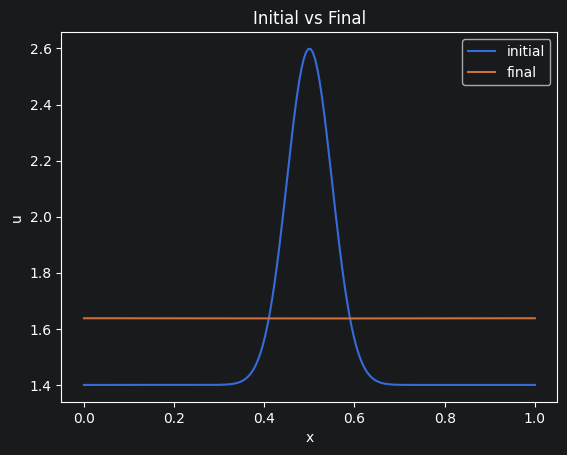

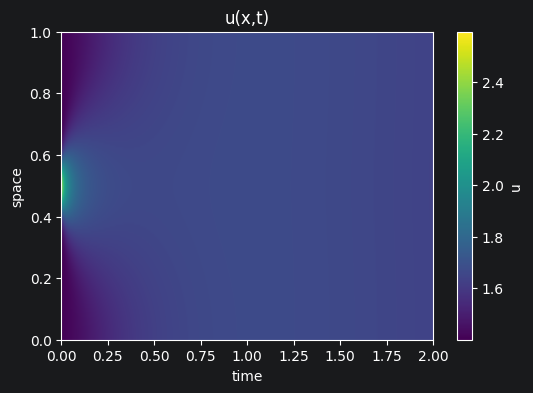

In [28]:
# 6. 初态 vs 末态
# =========================
plt.figure()
plt.plot(x, u0, label="initial")
plt.plot(x, u_hist[-1], label="final")
plt.legend()
plt.title("Initial vs Final")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

# =========================
# 7. space-time heatmap（最重要）
# =========================
plt.figure(figsize=(6, 4))
plt.imshow(u_hist.T, aspect="auto", origin="lower",
           extent=[0, params["T"], 0, 1])
plt.colorbar(label="u")
plt.xlabel("time")
plt.ylabel("space")
plt.title("u(x,t)")
plt.show()

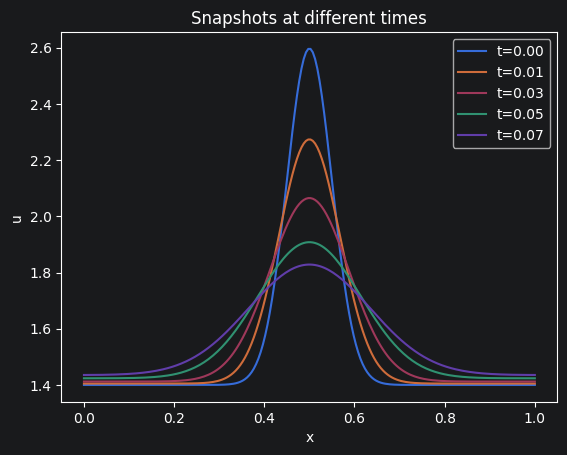

In [29]:
# 选择几个时间点（index）
time_indices = [0, 200, 500, 1000, 1500]

plt.figure()

for idx in time_indices:
    plt.plot(x, u_hist[idx], label=f"t={idx*params['dt']:.2f}")

plt.legend()
plt.xlabel("x")
plt.ylabel("u")
plt.title("Snapshots at different times")
plt.show()

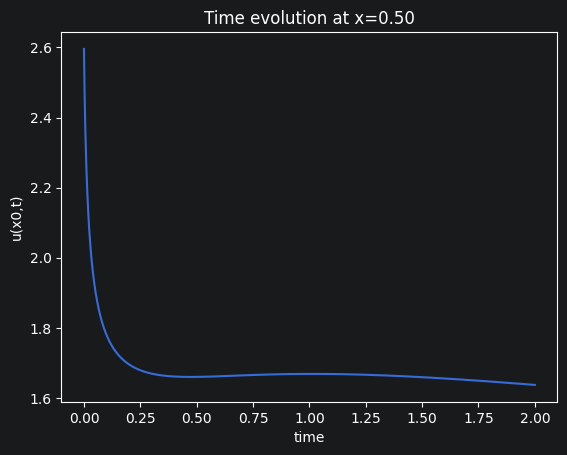

In [30]:
# 选空间点（中间）
i = N // 2

plt.figure()
plt.plot(np.linspace(0, params["T"], len(u_hist)), u_hist[:, i])

plt.xlabel("time")
plt.ylabel("u(x0,t)")
plt.title(f"Time evolution at x={x[i]:.2f}")
plt.show()